# Connect to google drive

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


# Set dataset paths

Unzip Autism emotion recogition dataset

In [11]:
!unzip -qqq /content/drive/MyDrive/drive_bys/'Autism emotion recogition dataset.zip'
aer_image_folder = '/content/Autism emotion recogition dataset/test/'

Unzip and load RAF-DB datasets in cwd

In [12]:
!unzip -qqq /content/drive/MyDrive/drive_bys/Image/aligned.zip
!cp /content/drive/MyDrive/drive_bys/EmoLabel/list_patition_label.txt .

In [13]:
#path to the images and labelfile
rafdb_image_folder = 'aligned'
rafdb_label_file = 'list_patition_label.txt'

Unzip and load FER datasets in cwd

In [14]:
!tar xvzf '/content/drive/MyDrive/drive_bys/FER/fer2013.tar.gz'
fer_csv_file = '/content/fer2013/fer2013.csv'

fer2013/fer2013.csv
fer2013/README
fer2013/fer2013.bib
fer2013/


Unzip and load Affectnet in cwd

In [ ]:
!unzip -qqqqq /content/drive/MyDrive/drive_bys/affectnet/affectnet.zip
affectnet_image_folder = '/content/archive (3)/Test'

# Install deepface and Imports

In [15]:
!pip install deepface -qqq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.2/169.2 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.7/171.7 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 3.3 MB/s eta 0:00:00


In [16]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import json
import cv2
from deepface import DeepFace
from google.colab.patches import cv2_imshow
from pathlib import Path
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import top_k_accuracy_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder

26-02-07 21:18:20 - Directory /root/.deepface has been created
26-02-07 21:18:20 - Directory /root/.deepface/weights has been created


# Preprocessing functions

Preprocessing and preparing RAF-DB for Deepface ingestion

In [17]:
def load_rafdb(image_folder, label_file,  split='train'):

    # 1. Paths Setup
    img_folder = image_folder
    label_file = label_file

    # 2. Parse the Label File
    df = pd.read_csv(label_file, sep=' ', header=None, names=['filename', 'label'])

    # 3. Filter by Split (Train vs Test)
    if split == 'train':
        df = df[df['filename'].str.startswith('train')]
    else:
        df = df[df['filename'].str.startswith('test')]

    df.reset_index(drop=True, inplace=True)

    # 4. Create a Full Path Column
    df['aligned_filename'] = df['filename'].str.replace('.jpg', '_aligned.jpg', regex=False)

    # construct the full paths by joining image_folder with the aligned filenames
    df['file_path'] = df['aligned_filename'].apply(lambda x: os.path.join(img_folder, x))
    df.drop(columns=['aligned_filename'], inplace=True)

    #mapping raf-db to the Deepface compatible naming scheme
    label_mapping = {
        1: 'surprise',
        2: 'fear',
        3: 'disgust',
        4: 'happy',
        5: 'sad',
        6: 'angry',
        7: 'neutral'
    }

    df['emotion_label'] = df['label'].map(label_mapping)

    return df

Preprocessing and preparing FER for Deepface ingestion

In [18]:
def load_fer(csv_file, split='train'):

    # 1. Read the CSV File
    df = pd.read_csv(csv_file)

    emotion_labels = {
    0: 'angry',
    1: 'disgust',
    2: 'fear',
    3: 'happy',
    4: 'sad',
    5: 'surprise',
    6: 'neutral'
    }

    df['emotion_label'] = df['emotion'].map(emotion_labels)

    if split == 'train':
      df = df[df['Usage'] == 'PublicTest']
    else:
      df = df[df['Usage'] == 'PublicTest']

    df.reset_index(drop=True, inplace=True)

    # create FER image data
    X_test = []

    for pixel_string in df['pixels']:
        pixels = [int(p) for p in pixel_string.split(' ')]
        pixels = np.array(pixels).reshape(48, 48)
        X_test.append(pixels)

    X_test = np.array(X_test, dtype='uint8')

    image_data = []
    for img in X_test:
      image = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
      image_data.append(image)

    return df, image_data


Preprocessing and preparing Affectnet for Deepface ingestion

In [19]:
def load_affectnet(image_folder, split='test'):

  image_folder = Path(image_folder)
  df = pd.DataFrame(columns=['file_path', 'emotion_label'])

  for emotion_folder in image_folder.iterdir():
      all_images = emotion_folder.glob('*')
      for image_name in all_images:
        image_path = image_name
        emotion_label = (emotion_folder.name).lower()
        df = pd.concat([df, pd.DataFrame({'file_path': [image_path], 'emotion_label': [emotion_label]})], ignore_index=True)

  label_mapping = {
    'anger': 'angry',
    'disgust': 'disgust',
    'fear': 'fear',
    'happy': 'happy',
    'sad': 'sad',
    'surprise': 'surprise',
    'neutral': 'neutral'
    }

  df = df[df['emotion_label'] != 'contempt']
  df.sort_values(by='file_path', inplace=True)
  df.reset_index(drop=True, inplace=True)

  df['emotion_label'] = df['emotion_label'].replace(label_mapping)

  return df

Preprocessing and preparing Austistic Facial Emotion Recognition for Deepface ingestion

In [30]:
def load_aer(image_folder, split='test'):

  image_folder = Path(image_folder)
  df = pd.DataFrame(columns=['file_path', 'emotion_label'])

  for emotion_folder in image_folder.iterdir():
      all_images = emotion_folder.glob('*')
      for image_name in all_images:
        image_path = image_name
        emotion_label = (emotion_folder.name).lower()
        df = pd.concat([df, pd.DataFrame({'file_path': [image_path], 'emotion_label': [emotion_label]})], ignore_index=True)

  label_mapping = {
    'anger': 'angry',
    'fear': 'fear',
    'sadness': 'sad',
    'surprise': 'surprise',
    'natural': 'neutral',
    'joy': 'happy'
    }

  df = df[df['emotion_label'] != 'contempt'] # Remove 'contempt' if present
  df.sort_values(by='file_path', inplace=True)
  df.reset_index(drop=True, inplace=True)

  df['emotion_label'] = df['emotion_label'].replace(label_mapping)

  return df

## Load the images

In [31]:
rafdb_df = load_rafdb(rafdb_image_folder, rafdb_label_file, split='test')
fer_df, fer_image_data = load_fer(fer_csv_file, split='test')
affectnet_df = load_affectnet(affectnet_image_folder, split='test')
aer_df = load_aer(aer_image_folder, split='test')

In [22]:
# The model expects input shape: (48, 48, 1)
def preprocess_for_emotion(img_path):

      img = cv2.imread(img_path)

      return img

print("Preprocessing images...")

# Apply preprocessing to all images
rafdb_image_data = np.array(rafdb_df['file_path'].apply(preprocess_for_emotion).tolist())
affectnet_image_data = np.array(affectnet_df['file_path'].apply(preprocess_for_emotion).tolist())
aer_image_data = np.array(aer_df['file_path'].apply(preprocess_for_emotion).tolist())

Preprocessing images...


#Run the models and generate predictions and store them

In [23]:
rafdf_results = DeepFace.analyze(rafdb_image_data, enforce_detection=False,  actions=['emotion'])

In [24]:
fer_results = DeepFace.analyze(fer_image_data, enforce_detection=False,  actions=['emotion'])

In [25]:
affectnet_results = DeepFace.analyze(affectnet_image_data, enforce_detection=False,  actions=['emotion'])

In [26]:
aer_results = DeepFace.analyze(aer_image_data, enforce_detection=False,  actions=['emotion'])

Save the results to a directory on Drive

In [27]:
def convert_numpy_floats(obj):
    """
    Recursively converts numpy float32 objects to standard Python floats
    within dictionaries and lists.
    """
    if isinstance(obj, dict):
        return {k: convert_numpy_floats(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_numpy_floats(elem) for elem in obj]
    elif isinstance(obj, np.float32):
        return float(obj)
    else:
        return obj

def save_results_to_drive(results, output_dir, output_filename):
    output_filepath = os.path.join(output_dir, output_filename)

    # Convert numpy.float32 to standard floats before saving
    serializable_results = convert_numpy_floats(results)

    # Save the results to a JSON file
    with open(output_filepath, 'w') as f:
        json.dump(serializable_results, f, indent=4)

    print(f"Results saved to: {output_filepath}")


In [ ]:
output_dir = '/content/drive/MyDrive/drive_bys/'
save_results_to_drive(rafdf_results, output_dir,'deepface_rafdb_test_results.json')
save_results_to_drive(fer_results, output_dir,'deepface_fer_test_results.json')
save_results_to_drive(affectnet_results, output_dir,'deepface_affectnet_test_results.json')
save_results_to_drive(aer_results, output_dir,'deepface_aer_test_results.json')

Results saved to: /content/drive/MyDrive/drive_bys/deepface_rafdb_test_results.json
Results saved to: /content/drive/MyDrive/drive_bys/deepface_fer_test_results.json
Results saved to: /content/drive/MyDrive/drive_bys/deepface_affectnet_test_results.json


# Get Top-1, Top-3, and F1 scores

Prepare probability matrix and Top-1 predictions

In [60]:
def prepare_probabilities(results, df, emotion_order, fer=False, aer=False):

  # 2. Extract Probabilities from DeepFace Results
  # results is the list of lists returned by DeepFace.analyze
  # We divide by 100 because DeepFace returns 0-100, but sklearn expects 0-1
  y_pred_proba = []

  # Iterate through the results corresponding to your dataframe rows
  for entry in results:
      # entry is a list of dicts (one per face). We take the first face [0].
      emotions_dict = entry[0]['emotion']

      # Extract values in the specific order
      probs = [emotions_dict[label] for label in emotion_order]
      y_pred_proba.append(probs)

  # Convert to numpy array and normalize to 0-1 range
  y_pred_proba = np.array(y_pred_proba) / 100.0

  # 3. Prepare Ground Truth
  # Map string labels from dataframe to integers (0-6) based on emotion_order
  le = LabelEncoder()
  le.fit(emotion_order) # Force the encoder to use our specific order

  if fer:
    y_true = df['emotion'].values

  else:
    y_true = le.transform(df['emotion_label'])

  # Get hard predictions (Top-1 class index)
  y_pred = np.argmax(y_pred_proba, axis=1)
  return y_pred_proba, y_pred, y_true


In [32]:
#Define the exact order DeepFace uses (based on your output)
emotion_order = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
aer_emotion_order = ['angry', 'fear', 'happy', 'sad', 'surprise', 'neutral']


rafdb_y_pred_proba, rafdb_y_pred, rafdb_y_true = prepare_probabilities(rafdf_results, rafdb_df, emotion_order)
fer_y_pred_proba, fer_y_pred, fer_y_true = prepare_probabilities(fer_results, fer_df, emotion_order, fer=True)
affectnet_y_pred_proba, affectnet_y_pred, affectnet_y_true = prepare_probabilities(affectnet_results, affectnet_df, emotion_order)
aer_y_pred_proba, aer_y_pred, aer_y_true = prepare_probabilities(aer_results, aer_df, aer_emotion_order, aer=True)

In [61]:
aer_y_pred_proba, aer_y_pred, aer_y_true = prepare_probabilities(aer_results, aer_df, aer_emotion_order, aer=True)

In [39]:
def get_scores(y_pred_proba, y_pred, y_true, dataset, emotion_order):
    # --- 1. Top-1 Accuracy ---
  top1_acc = top_k_accuracy_score(y_true, y_pred_proba, k=1)

  # --- 2. Top-3 Accuracy ---
  top3_acc = top_k_accuracy_score(y_true, y_pred_proba, k=3)

  # --- 3. F1 Score ---
  # "Macro" gives equal weight to all classes (good for checking performance on rare emotions like disgust)
  # "Weighted" accounts for class imbalance
  f1_macro = f1_score(y_true, y_pred, average='macro')
  f1_weighted = f1_score(y_true, y_pred, average='weighted')

  # Per-class F1 breakdown
  report = classification_report(y_true, y_pred, target_names=emotion_order)

  print(f"Top-1 Accuracy: {top1_acc:.4f}")
  print(f"Top-3 Accuracy: {top3_acc:.4f}")
  print(f"F1 Score (Macro): {f1_macro:.4f}")
  print(f"F1 Score (Weighted):{f1_macro:.4f}")
  print("-" * 30)
  print("Per-Class Report:\n", report)

  return {
      'dataset':  dataset,
      'top1_acc': top1_acc,
      'top3_acc': top3_acc,
      'f1_macro': f1_macro,
      'f1_weighted': f1_weighted,
      'report': report}

In [34]:
rafdb_scores = get_scores(rafdb_y_pred_proba, rafdb_y_pred, rafdb_y_true, 'rafdb')

Top-1 Accuracy: 0.3862
Top-3 Accuracy: 0.6630
F1 Score (Macro): 0.2235
F1 Score (Weighted):0.2235
------------------------------
Per-Class Report:
               precision    recall  f1-score   support

       angry       0.24      0.43      0.31       162
     disgust       0.13      0.01      0.02       160
        fear       0.08      0.23      0.12        74
       happy       0.74      0.75      0.75      1185
         sad       0.25      0.15      0.19       680
    surprise       0.07      0.01      0.02       478
     neutral       0.12      0.30      0.17       329

    accuracy                           0.39      3068
   macro avg       0.23      0.27      0.22      3068
weighted avg       0.38      0.39      0.37      3068



In [35]:
fer_scores = get_scores(fer_y_pred_proba, fer_y_pred, fer_y_true, 'fer')

Top-1 Accuracy: 0.5520
Top-3 Accuracy: 0.8442
F1 Score (Macro): 0.5161
F1 Score (Weighted):0.5161
------------------------------
Per-Class Report:
               precision    recall  f1-score   support

       angry       0.48      0.43      0.45       467
     disgust       0.57      0.29      0.38        56
        fear       0.38      0.37      0.38       496
       happy       0.78      0.78      0.78       895
         sad       0.44      0.42      0.43       653
    surprise       0.76      0.69      0.73       415
     neutral       0.41      0.52      0.46       607

    accuracy                           0.55      3589
   macro avg       0.55      0.50      0.52      3589
weighted avg       0.56      0.55      0.55      3589



In [36]:
affectnet_scores = get_scores(affectnet_y_pred_proba, affectnet_y_pred, affectnet_y_true, 'affectnet')

Top-1 Accuracy: 0.3162
Top-3 Accuracy: 0.6142
F1 Score (Macro): 0.2668
F1 Score (Weighted):0.2668
------------------------------
Per-Class Report:
               precision    recall  f1-score   support

       angry       0.33      0.31      0.32      1718
     disgust       0.60      0.06      0.12      1248
        fear       0.26      0.29      0.28      1664
       happy       0.70      0.76      0.73      2704
         sad       0.25      0.23      0.24      2368
    surprise       0.03      0.02      0.02      1584
     neutral       0.13      0.24      0.17      1920

    accuracy                           0.32     13206
   macro avg       0.33      0.27      0.27     13206
weighted avg       0.34      0.32      0.31     13206



In [62]:
aer_scores = get_scores(aer_y_pred_proba, aer_y_pred, aer_y_true, 'aer', aer_emotion_order)

Top-1 Accuracy: 0.2522
Top-3 Accuracy: 0.6681
F1 Score (Macro): 0.2383
F1 Score (Weighted):0.2383
------------------------------
Per-Class Report:
               precision    recall  f1-score   support

       angry       0.40      0.15      0.22        40
        fear       0.24      0.19      0.22        36
       happy       0.46      0.74      0.57        35
         sad       0.08      0.10      0.09        40
    surprise       0.50      0.08      0.14        38
     neutral       0.15      0.30      0.20        37

    accuracy                           0.25       226
   macro avg       0.31      0.26      0.24       226
weighted avg       0.30      0.25      0.23       226



# Compute ECE scores for each dataset

In [63]:
def compute_ece(y_true, y_pred_proba, n_bins=10, dataset=''):
    """
    Computes Expected Calibration Error (ECE) for multi-class classification.

    Args:
        y_true (array): True integer labels (N,)
        y_pred_proba (array): Predicted probabilities (N, C)
        n_bins (int): Number of bins for calibration
    """
    # 1. Get the max probability (confidence) and the predicted class for each sample
    confidences = np.max(y_pred_proba, axis=1)
    predictions = np.argmax(y_pred_proba, axis=1)

    # 2. Check correctness
    accuracies = (predictions == y_true)

    # 3. Define bin boundaries (0.0 to 1.0)
    bin_boundaries = np.linspace(0, 1, n_bins + 1)

    ece = 0.0
    total_samples = len(y_true)

    for i in range(n_bins):
        # Find samples that fall into this confidence bin
        lower = bin_boundaries[i]
        upper = bin_boundaries[i + 1]

        # Mask for samples in this bin
        in_bin = (confidences > lower) & (confidences <= upper)
        prop_in_bin = np.mean(in_bin) # Proportion of samples in this bin

        if prop_in_bin > 0:
            # Accuracy in this bin: mean(correctness)
            accuracy_in_bin = np.mean(accuracies[in_bin])

            # Confidence in this bin: mean(confidence)
            confidence_in_bin = np.mean(confidences[in_bin])

            # Absolute difference * weight
            ece += np.abs(accuracy_in_bin - confidence_in_bin) * prop_in_bin

    print(f"Expected Calibration Error (ECE) for {dataset}: {ece:.4f}")
    return ece

In [64]:
rafdb_ece = compute_ece(rafdb_y_true, rafdb_y_pred_proba, dataset='rafdb')
rafdb_scores['ece'] = rafdb_ece

Expected Calibration Error (ECE) for rafdb: 0.4420


In [65]:
fer_ece = compute_ece(fer_y_true, fer_y_pred_proba, dataset='fer')
fer_scores['ece'] = fer_ece

Expected Calibration Error (ECE) for fer: 0.2748


In [66]:
affectnet_ece = compute_ece(affectnet_y_true, affectnet_y_pred_proba, dataset='affectnet')
affectnet_scores['ece'] = affectnet_ece

Expected Calibration Error (ECE) for affectnet: 0.4665


In [67]:
aer_ece = compute_ece(aer_y_true, aer_y_pred_proba, dataset='aer')
aer_scores['ece'] = aer_ece

Expected Calibration Error (ECE) for aer: 0.5605


# Show Confusion Matrix for the datasets

In [68]:
def show_confusion_matrix(y_true, y_pred, emotion_order, dataset):
  cm = confusion_matrix(y_true, y_pred)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=emotion_order)

  fig, ax = plt.subplots(figsize=(8, 6))
  disp.plot(cmap=plt.cm.Blues, ax=ax)
  plt.title(f'Confusion Matrix for DeepFace Emotion Recognition on {dataset}')
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')
  plt.xticks(rotation=45, ha='right')
  plt.tight_layout()
  plt.show()



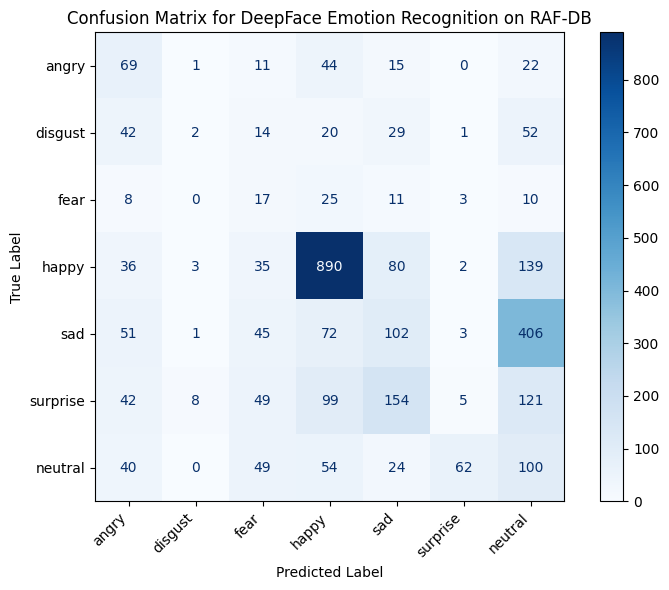

In [69]:
show_confusion_matrix(rafdb_y_true, rafdb_y_pred, emotion_order, 'RAF-DB')

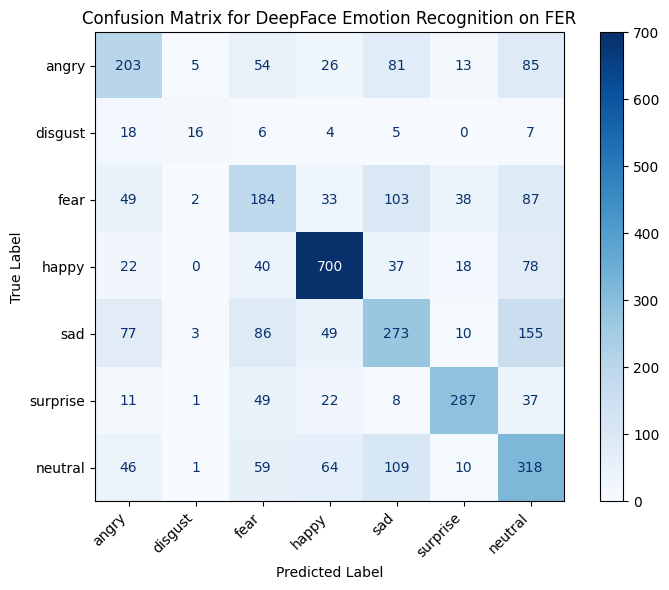

In [70]:
show_confusion_matrix(fer_y_true, fer_y_pred, emotion_order, 'FER')

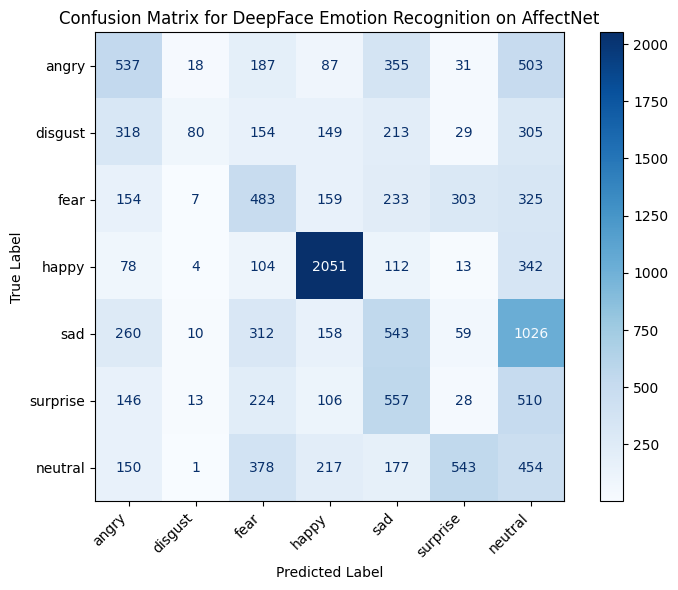

In [71]:
show_confusion_matrix(affectnet_y_true, affectnet_y_pred, emotion_order, 'AffectNet')

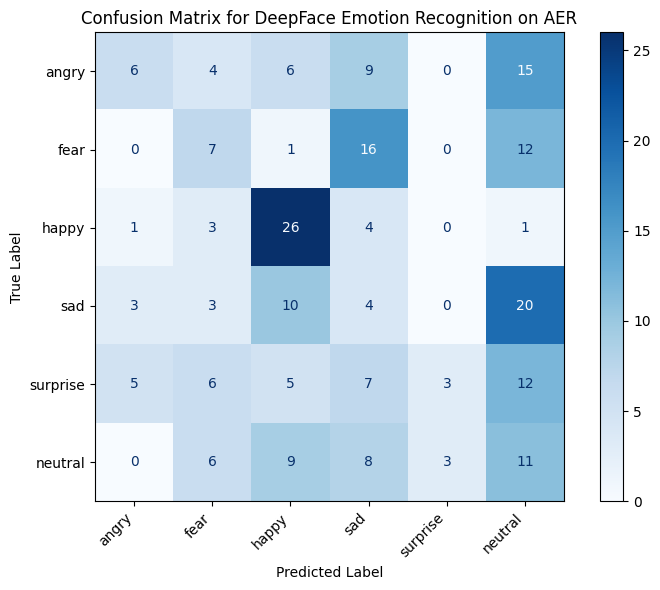

In [72]:
show_confusion_matrix(aer_y_true, aer_y_pred, aer_emotion_order, 'AER')

# Create Reliability Diagram for the datasets

In [73]:
def plot_reliability_diagram(y_true, y_prob, n_bins=15, dataset=""):
    """
    Plots a multiclass reliability diagram.

    Args:
        y_true: Array of true class indices (0..N).
        y_prob: Array of predicted probabilities (N_samples, N_classes).
        n_bins: Number of bins for the calibration curve.
    """
    # 1. Get the Confidence (max prob) and Prediction for each sample
    confidences = np.max(y_prob, axis=1)
    predictions = np.argmax(y_prob, axis=1)

    # 2. Determine if prediction was correct
    accuracies = (predictions == y_true)

    # 3. Create Bins
    bin_boundaries = np.linspace(0, 1, n_bins + 1)

    bin_accuracies = []
    bin_confidences = []
    bin_counts = []

    for i in range(n_bins):
        # Define bin range
        lower, upper = bin_boundaries[i], bin_boundaries[i+1]

        # Find samples in this bin
        in_bin = (confidences > lower) & (confidences <= upper)
        count = np.sum(in_bin)
        bin_counts.append(count)

        if count > 0:
            # Calculate average accuracy and confidence for this bin
            bin_accuracies.append(np.mean(accuracies[in_bin]))
            bin_confidences.append(np.mean(confidences[in_bin]))
        else:
            bin_accuracies.append(0)
            bin_confidences.append((lower + upper) / 2)

    # --- PLOTTING ---
    plt.figure(figsize=(10, 10))

    # Subplot 1: The Reliability Curve
    ax1 = plt.subplot2grid((3, 1), (0, 0), rowspan=2)

    # Perfect calibration line (Diagonal)
    ax1.plot([0, 1], [0, 1], "k:", label="Perfectly Calibrated")

    # The Model's curve
    ax1.plot(bin_confidences, bin_accuracies, "s-", label="Model Calibration")

    # Fill areas to highlight over/under confidence
    ax1.fill_between(bin_confidences, bin_confidences, bin_accuracies,
                     where=np.array(bin_accuracies) < np.array(bin_confidences),
                     color='red', alpha=0.2, label="Overconfidence Gap")

    ax1.set_ylabel("Observed Accuracy")
    ax1.set_ylim([0, 1])
    ax1.set_xlim([0, 1])
    ax1.set_title(f"Reliability Diagram (Deepface on {dataset})")
    ax1.legend(loc="upper left")
    ax1.grid(True, alpha=0.3)

    # Subplot 2: Confidence Histogram (How many samples in each bin?)
    ax2 = plt.subplot2grid((3, 1), (2, 0))
    ax2.hist(confidences, bins=bin_boundaries, alpha=0.7, color='gray', edgecolor='black')
    ax2.set_xlabel("Predicted Confidence")
    ax2.set_ylabel("Count")
    ax2.set_xlim([0, 1])
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
# plot_reliability_diagram(y_true, y_pred_proba, n_bins=15, )

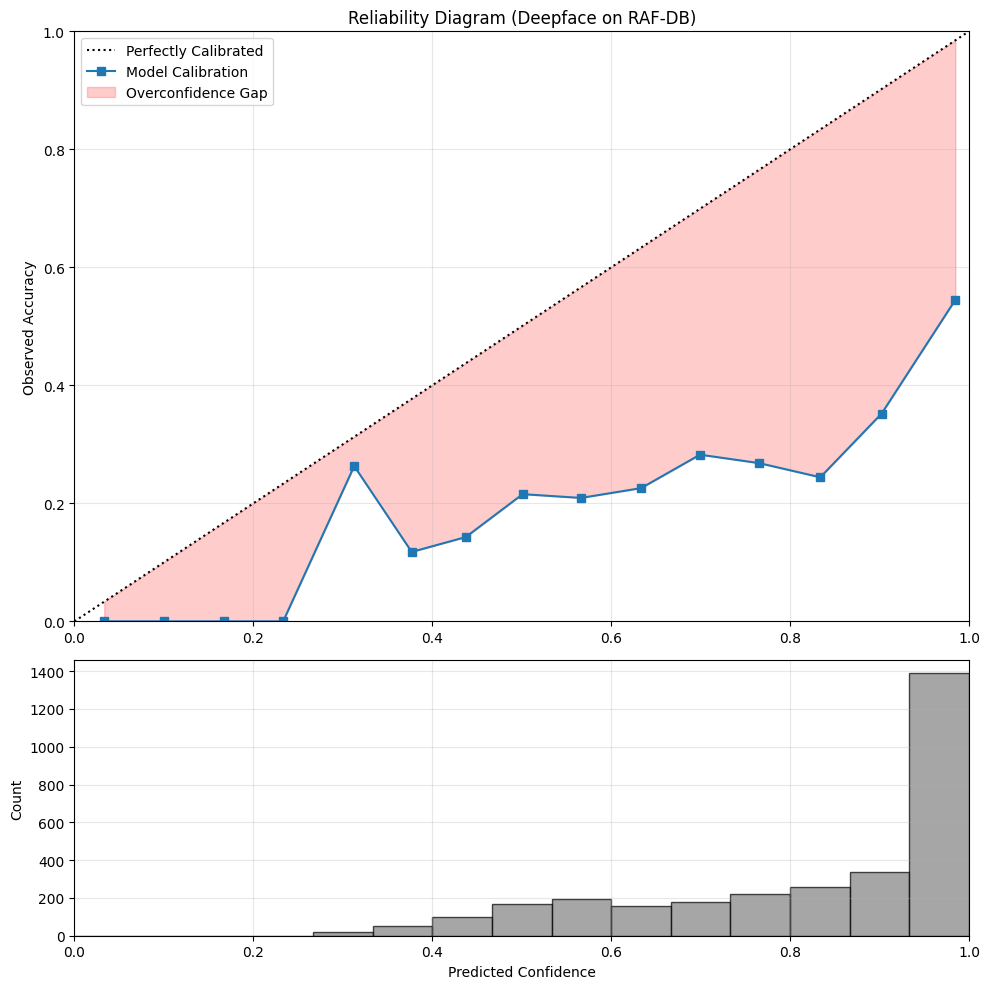

In [74]:
plot_reliability_diagram(rafdb_y_true, rafdb_y_pred_proba, dataset='RAF-DB')

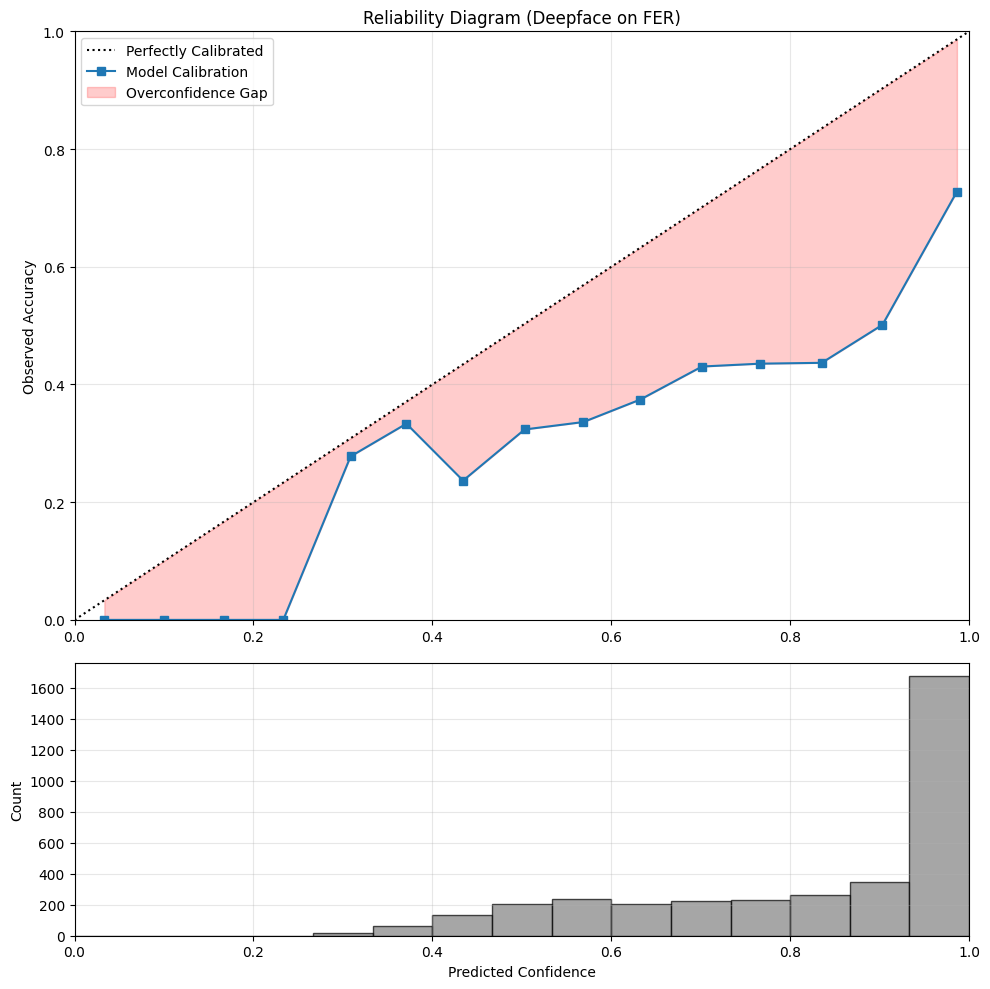

In [75]:
plot_reliability_diagram(fer_y_true, fer_y_pred_proba, dataset='FER')

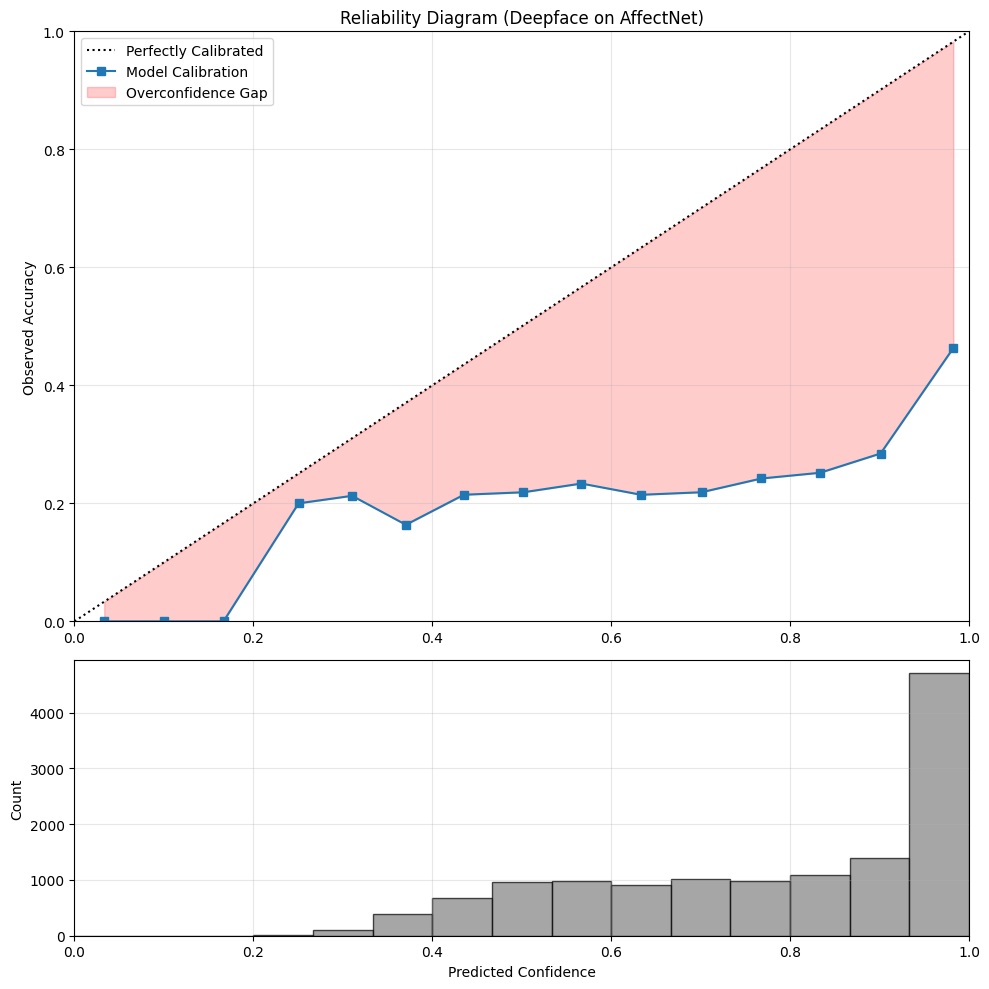

In [76]:
plot_reliability_diagram(affectnet_y_true, affectnet_y_pred_proba, dataset='AffectNet')

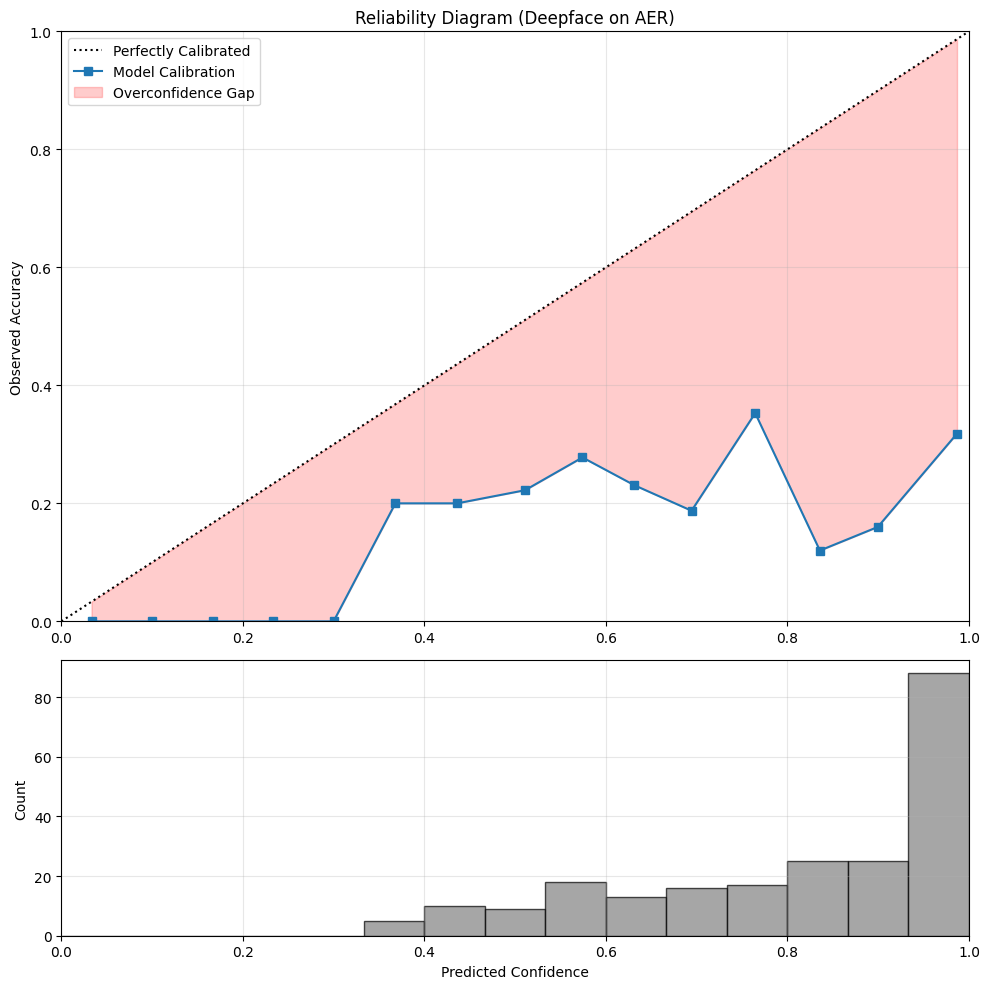

In [77]:
plot_reliability_diagram(aer_y_true, aer_y_pred_proba, dataset='AER')